# Data Analysis 2 Hw2

In [1]:
import warnings

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from plotnine import *
from skimpy import skim
from stargazer.stargazer import Stargazer
import statsmodels.formula.api as smf
from mizani.formatters import percent_format
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import log_loss

%matplotlib inline
warnings.filterwarnings("ignore")

### Load and prepare datasets

In [2]:
#read data from provided link
#hotels_europe_price = pd.read_csv("https://osf.io/p6tyr/download")
#hotels_europe_features = pd.read_csv("https://osf.io/utwjs/download")

hotels_europe_price = pd.read_csv("hotels-europe_price (1).csv")
hotels_europe_features = pd.read_csv("hotels-europe_features (1).csv")


In [3]:
# join datasets
europe = hotels_europe_price.merge(hotels_europe_features, on = "hotel_id")
europe.head()

,hotel_id,price,offer,offer_cat,year,month,weekend,holiday,nnights,scarce_room,...,country,city_actual,rating_reviewcount,center1label,center2label,neighbourhood,ratingta,ratingta_count,distance_alter,accommodation_type
0,1,172,0,0% no offer,2017,11,1,0,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
1,1,122,1,15-50% offer,2018,1,1,0,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
2,1,122,1,15-50% offer,2017,12,0,1,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
3,1,552,1,1-15% offer,2017,12,0,1,4,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
4,1,122,1,15-50% offer,2018,2,1,0,1,0,...,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel


In [4]:
# create new binary variable
europe["highly_rated"] = np.where(europe["rating"] >= 4, 1, 0)
europe.head(10)

# filter the city: Salzburg
salzburg = (
    europe.loc[lambda x: x["accommodation_type"] == "Hotel"]
    .loc[lambda x: x["city_actual"] == "Salzburg"]
    .loc[lambda x: x["stars"].notnull()]
)

salzburg


,hotel_id,price,offer,offer_cat,year,month,weekend,holiday,nnights,scarce_room,...,city_actual,rating_reviewcount,center1label,center2label,neighbourhood,ratingta,ratingta_count,distance_alter,accommodation_type,highly_rated
127748,20151,164,1,1-15% offer,2018,2,1,0,1,1,...,Salzburg,61.0,City centre,Smaragd II Ski Lift,Altstadt,4.5,140.0,51.0,Hotel,1
127749,20151,173,0,0% no offer,2017,11,0,0,1,1,...,Salzburg,61.0,City centre,Smaragd II Ski Lift,Altstadt,4.5,140.0,51.0,Hotel,1
127750,20151,733,0,0% no offer,2017,12,0,1,4,1,...,Salzburg,61.0,City centre,Smaragd II Ski Lift,Altstadt,4.5,140.0,51.0,Hotel,1
127751,20152,2047,0,0% no offer,2017,12,0,1,4,0,...,Salzburg,107.0,City centre,Smaragd II Ski Lift,Altstadt,4.5,1018.0,50.0,Hotel,1
127752,20152,319,1,15-50% offer,2017,11,0,0,1,1,...,Salzburg,107.0,City centre,Smaragd II Ski Lift,Altstadt,4.5,1018.0,50.0,Hotel,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129150,20427,61,1,50%-75% offer,2017,11,0,0,1,1,...,Salzburg,36.0,City centre,Smaragd II Ski Lift,Schallmoos,2.0,71.0,51.0,Hotel,0
129151,20427,489,1,1-15% offer,2017,12,0,1,4,1,...,Salzburg,36.0,City centre,Smaragd II Ski Lift,Schallmoos,2.0,71.0,51.0,Hotel,0
129152,20427,88,1,15-50% offer,2018,6,1,0,1,0,...,Salzburg,36.0,City centre,Smaragd II Ski Lift,Schallmoos,2.0,71.0,51.0,Hotel,0
129153,20427,91,1,15-50% offer,2018,5,1,0,1,0,...,Salzburg,36.0,City centre,Smaragd II Ski Lift,Schallmoos,2.0,71.0,51.0,Hotel,0


### Data Cleaning

In [5]:
# Drop any duplicates
salzburg_clean = salzburg.drop_duplicates()
salzburg_clean.shape

(564, 25)

In [6]:
# Check for missing values
salzburg_clean.isna().sum()

hotel_id              0
price                 0
offer                 0
offer_cat             0
year                  0
month                 0
weekend               0
holiday               0
nnights               0
scarce_room           0
city                  0
distance              0
stars                 0
rating                0
country               0
city_actual           0
rating_reviewcount    0
center1label          0
center2label          0
neighbourhood         0
ratingta              0
ratingta_count        0
distance_alter        0
accommodation_type    0
highly_rated          0
dtype: int64

In [7]:
# Filter columns to only necessary variables 
salzburg_clean = salzburg_clean[["hotel_id", "highly_rated", "distance", "stars", 'price']]
salzburg_clean.head(5)

,hotel_id,highly_rated,distance,stars,price
127748,20151,1,0.6,4.0,164
127749,20151,1,0.6,4.0,173
127750,20151,1,0.6,4.0,733
127751,20152,1,0.3,5.0,2047
127752,20152,1,0.3,5.0,319


## Examining Relationships 

Between high rating and other accomodation features

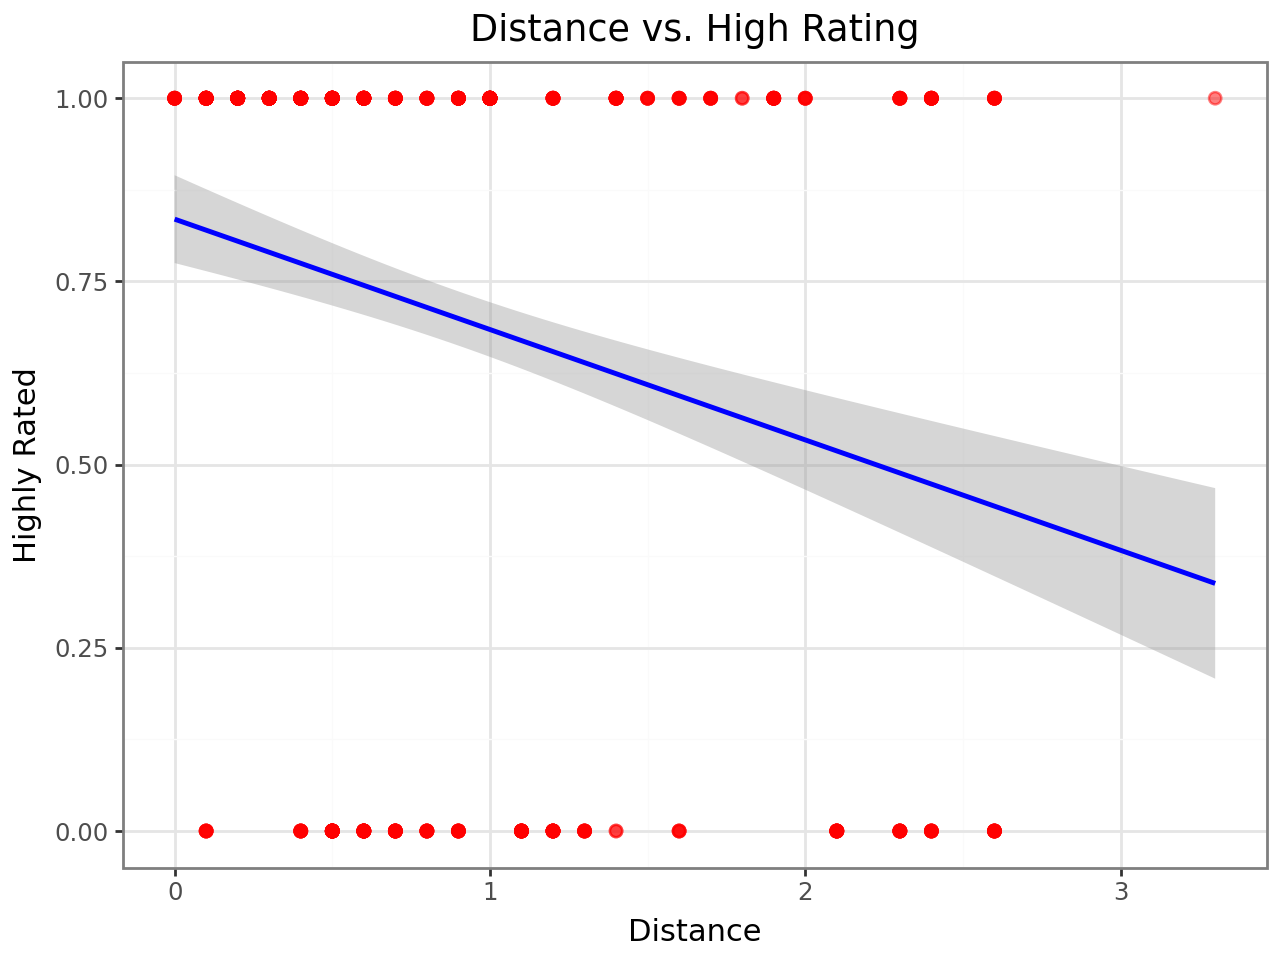

In [8]:
# Rating and distance
p1 = (ggplot(data=salzburg_clean)
    + geom_point(aes(x="distance", y="highly_rated"), color="red", size=2, alpha=0.5)
    + labs(x="Distance", y="Highly Rated")
    + theme_bw()
    + geom_smooth(aes(x="distance", y="highly_rated"),method="lm",color="blue",formula="y~x")
    + labs(title= "Distance vs. High Rating")
    )
p1

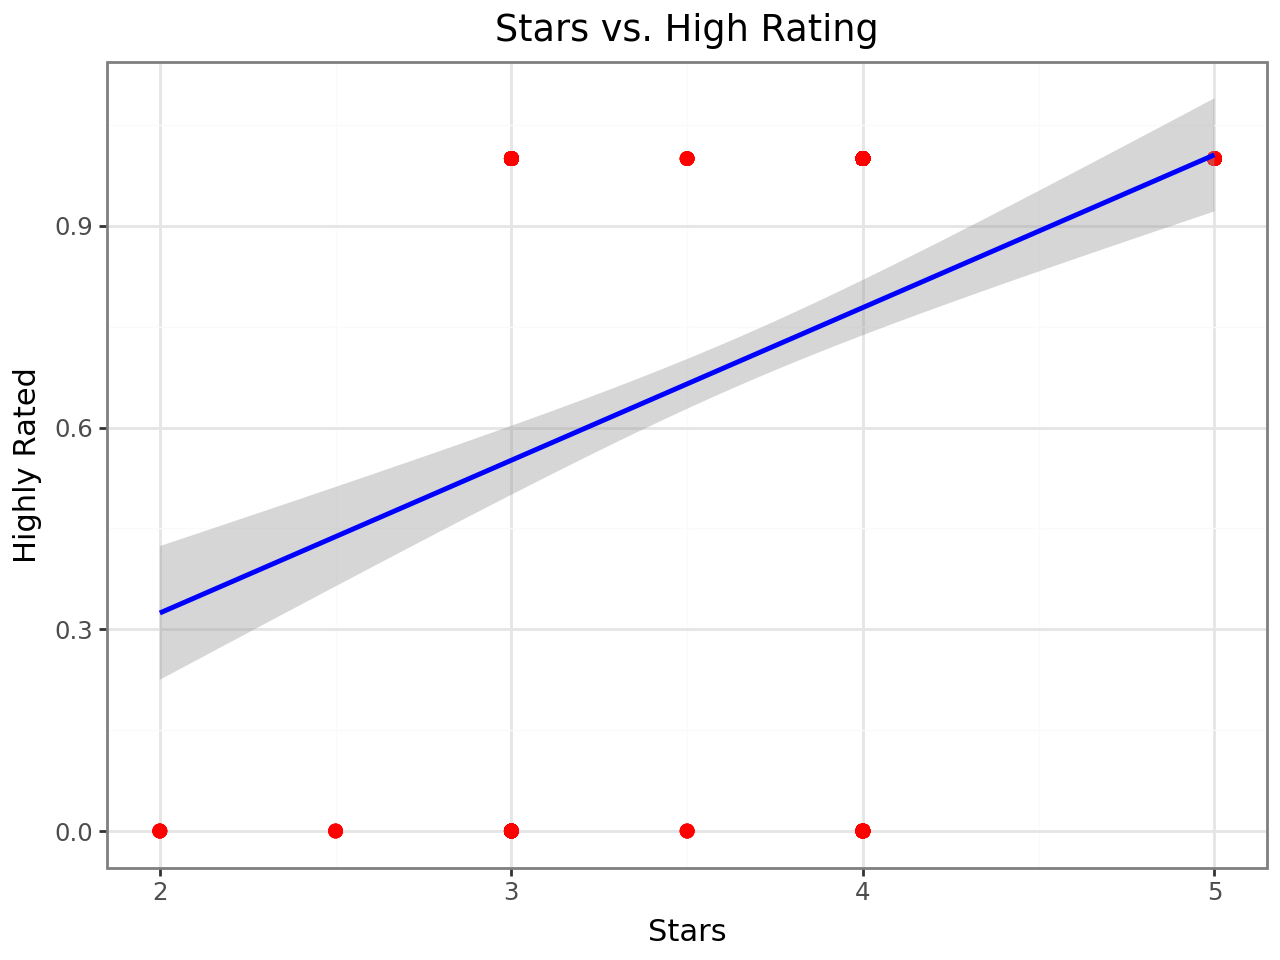

In [9]:
# Rating and Stars
p1 = (ggplot(data=salzburg_clean)
    + geom_point(aes(x="stars", y="highly_rated"), color="red", size=2, alpha=0.5)
    + labs(x="Stars", y="Highly Rated")
    + theme_bw()
    + geom_smooth(aes(x="stars", y="highly_rated"),method="lm",color="blue",formula="y~x")
    + labs(title= "Stars vs. High Rating")
    )
p1

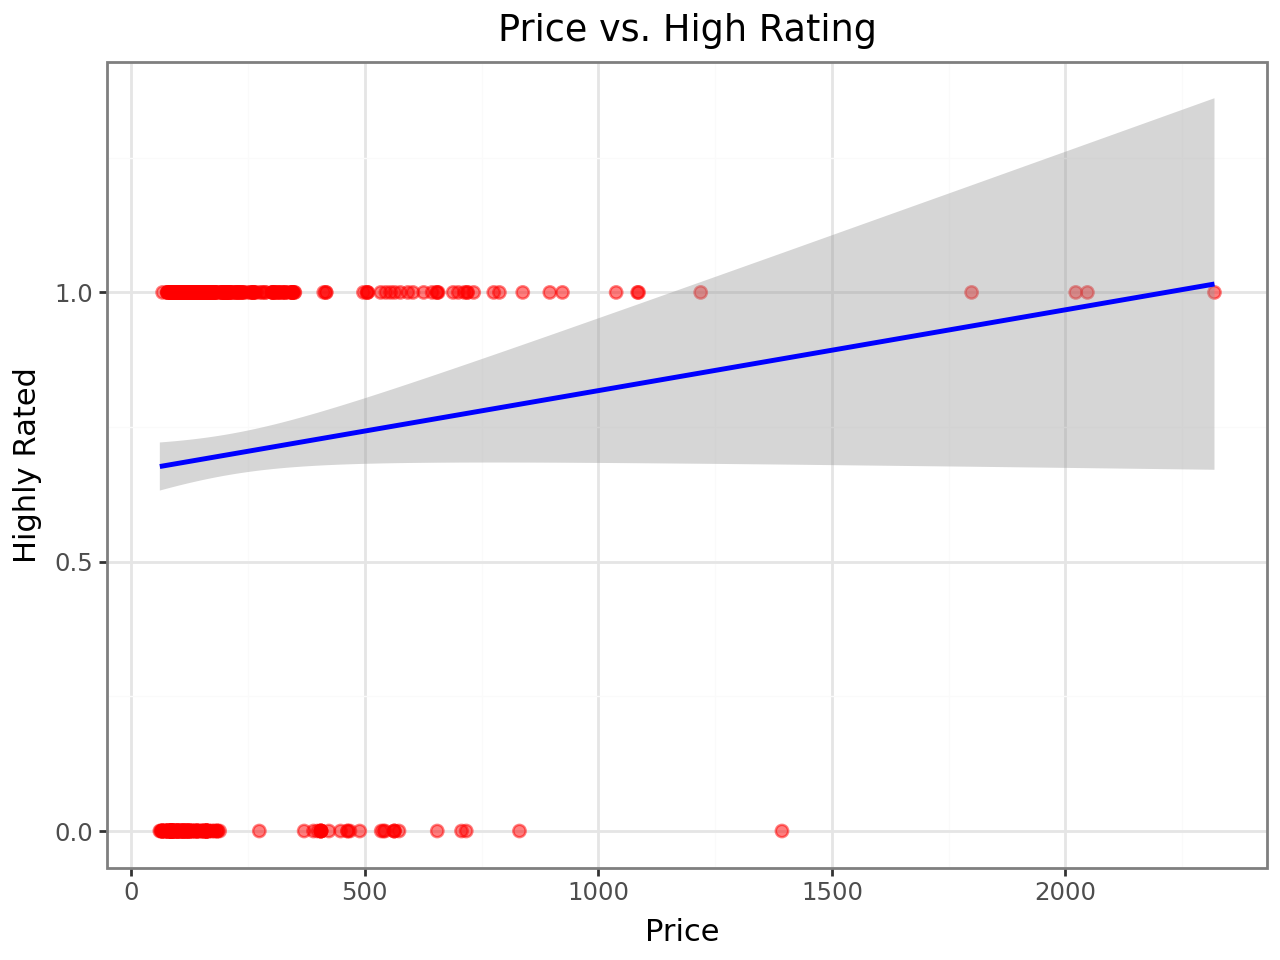

In [10]:
# Rating and Price
p3 = (ggplot(data=salzburg_clean)
    + geom_point(aes(x="price", y="highly_rated"), color="red", size=2, alpha=0.5)
    + labs(x="Price ", y="Highly Rated")
    + theme_bw()
    + geom_smooth(aes(x="price", y="highly_rated"),method="lm",color="blue",formula="y~x")
    + labs(title= "Price vs. High Rating")
    )
p3

## Linear Probability Model

### Model

In [11]:
lpm1 = smf.ols("highly_rated ~ stars + distance + price", data=salzburg_clean).fit(cov_type ="HC3")
lpm1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           highly_rated   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     34.33
Date:                Mon, 15 Dec 2025   Prob (F-statistic):           2.22e-20
Time:                        18:47:13   Log-Likelihood:                -324.32
No. Observations:                 564   AIC:                             656.6
Df Residuals:                     560   BIC:                             674.0
Df Model:                           3                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0741      0.120      0.616      0.538      -0.162       0.310
stars          0.1986      0.029      6.851      0.000       0.142       0.255
distance      -0.0989      0.030     -3.289      0.001      -0.158      -0.040
price      -5.031e-05   6.22e-05     -0.808      0.419      -0.000    7.17e-05
==============================================================================
Omnibus:                      168.463   Durbin-Watson:                   0.301
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               67.563
Skew:                          -0.674   Prob(JB):                     2.13e-15
Kurtosis:                       1.972   Cond. No.                     2.13e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 2.13e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Predictions

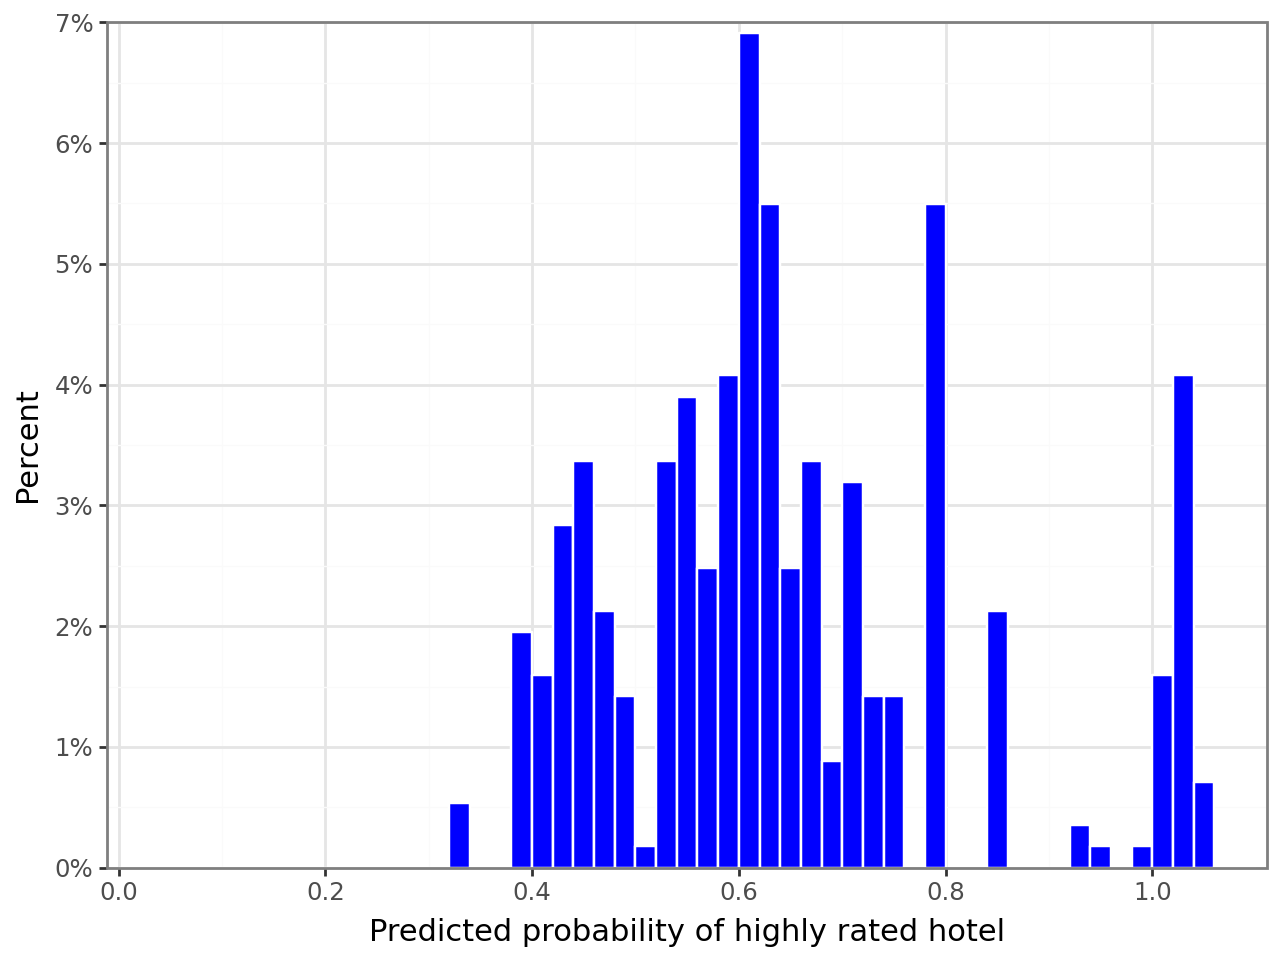

In [12]:
#predict probabilities
salzburg_clean["pred_lpm"] = lpm1.predict()
salzburg_clean['pred_lpm'].describe().round(4)

#show the predicted probabilities distribution
(
    ggplot(salzburg_clean, aes(x="pred_lpm"))
    + geom_histogram(
        aes(y="stat(count)/sum(stat(count))"),
        binwidth=0.02,
        center=0.65,
        color="white",
        fill="blue",
        closed="right",
        na_rm=True
    )
    + labs(x="Predicted probability of highly rated hotel", y="Percent")
    + scale_y_continuous(
        expand=[0.00, 0.0],
        limits=[0, 0.07],
        breaks=np.arange(0, 0.07, 0.01),
        labels=percent_format(),
    )
    + scale_x_continuous(
        expand=[0.001, 0.01], limits=[0, 1.1], breaks=np.arange(0, 1.1, 0.2)
    )
    + theme_bw()
)

## Logit Model

### Model

In [13]:
formula = "highly_rated ~ stars + distance + price"
logit = smf.logit(formula, salzburg_clean).fit()
table = Stargazer([logit])
table

Optimization terminated successfully.
         Current function value: 0.547698
         Iterations 6


### Predictions

In [ ]:
salzburg_clean["pred_logit"] = logit.predict()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:           highly_rated
Method:                          dydx
At:                           overall
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
stars          0.1971      0.028      7.102      0.000       0.143       0.251
distance      -0.0904      0.024     -3.760      0.000      -0.138      -0.043
price      -2.116e-05   9.27e-05     -0.228      0.819      -0.000       0.000
==============================================================================
"""

### Marginal Differences

In [22]:
logit.get_margeff().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
        Logit Marginal Effects       
=====================================
Dep. Variable:           highly_rated
Method:                          dydx
At:                           overall
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
stars          0.1971      0.028      7.102      0.000       0.143       0.251
distance      -0.0904      0.024     -3.760      0.000      -0.138      -0.043
price      -2.116e-05   9.27e-05     -0.228      0.819      -0.000       0.000
==============================================================================
"""

## Probit Model

### Model

In [15]:
formula = "highly_rated ~ stars + distance + price"
probit = smf.probit(formula, salzburg_clean).fit()
table = Stargazer([probit])
table

Optimization terminated successfully.
         Current function value: 0.546264
         Iterations 6


### Predictions

In [ ]:
salzburg_clean["pred_probit"] = probit.predict()

<class 'statsmodels.iolib.summary.Summary'>
"""
       Probit Marginal Effects       
=====================================
Dep. Variable:           highly_rated
Method:                          dydx
At:                           overall
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
stars          0.2007      0.028      7.071      0.000       0.145       0.256
distance      -0.0936      0.024     -3.841      0.000      -0.141      -0.046
price      -1.365e-05   9.27e-05     -0.147      0.883      -0.000       0.000
==============================================================================
"""

### Marginal Differences

In [23]:
probit.get_margeff().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
       Probit Marginal Effects       
=====================================
Dep. Variable:           highly_rated
Method:                          dydx
At:                           overall
==============================================================================
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
stars          0.2007      0.028      7.071      0.000       0.145       0.256
distance      -0.0936      0.024     -3.841      0.000      -0.141      -0.046
price      -1.365e-05   9.27e-05     -0.147      0.883      -0.000       0.000
==============================================================================
"""

## Comparing results of the 3 models

### Models

In [17]:
table = Stargazer([lpm1,logit,probit])
table

### Predictions

In [18]:
salzburg_clean.filter(["pred_lpm","pred_logit","pred_probit"]).describe().T

,count,mean,std,min,25%,50%,75%,max
pred_lpm,564.0,0.698582,0.160265,0.329227,0.588872,0.715232,0.813499,1.041323
pred_logit,564.0,0.698582,0.163314,0.264806,0.596639,0.744382,0.826416,0.942925
pred_probit,564.0,0.699265,0.166253,0.264825,0.593176,0.740278,0.828595,0.956680


## Results detailed

In [19]:
pd.DataFrame(
    {
        "R-squared": [
            lpm1.rsquared,
            r2_score(salzburg_clean["highly_rated"], salzburg_clean["pred_logit"]),
            r2_score(salzburg_clean["highly_rated"], salzburg_clean["pred_probit"]),
        ],
        "Brier-score": [
            mean_squared_error(salzburg_clean["highly_rated"], salzburg_clean["pred_lpm"]),
            mean_squared_error(salzburg_clean["highly_rated"], salzburg_clean["pred_logit"]),
            mean_squared_error(salzburg_clean["highly_rated"], salzburg_clean["pred_probit"]),
        ],
        "Pseudo R-squared": [np.nan, logit.prsquared, probit.prsquared],
        "Log-loss": [
            np.nan,         # no log loss for LPM
            -1 * log_loss(salzburg_clean["highly_rated"], salzburg_clean["pred_logit"]),
            -1 * log_loss(salzburg_clean["highly_rated"], salzburg_clean["pred_probit"]),
        ],
    },
    index=["LPM", "Logit", "Probit"],
).T.round(3)

,LPM,Logit,Probit
R-squared,0.122,0.116,0.117
Brier-score,0.185,0.186,0.186
Pseudo R-squared,NaN,0.105,0.108
Log-loss,NaN,-0.548,-0.546


## Visualization of Models

In [20]:
df_plot = pd.melt(
    salzburg_clean[["pred_lpm", "pred_logit", "pred_probit"]].rename(
        columns={"pred_logit": "Logit", "pred_probit": "Probit"}
    ),
    value_vars=["Logit", "Probit"],
    id_vars=["pred_lpm"],
).sort_values(by=["variable"], ascending=False)


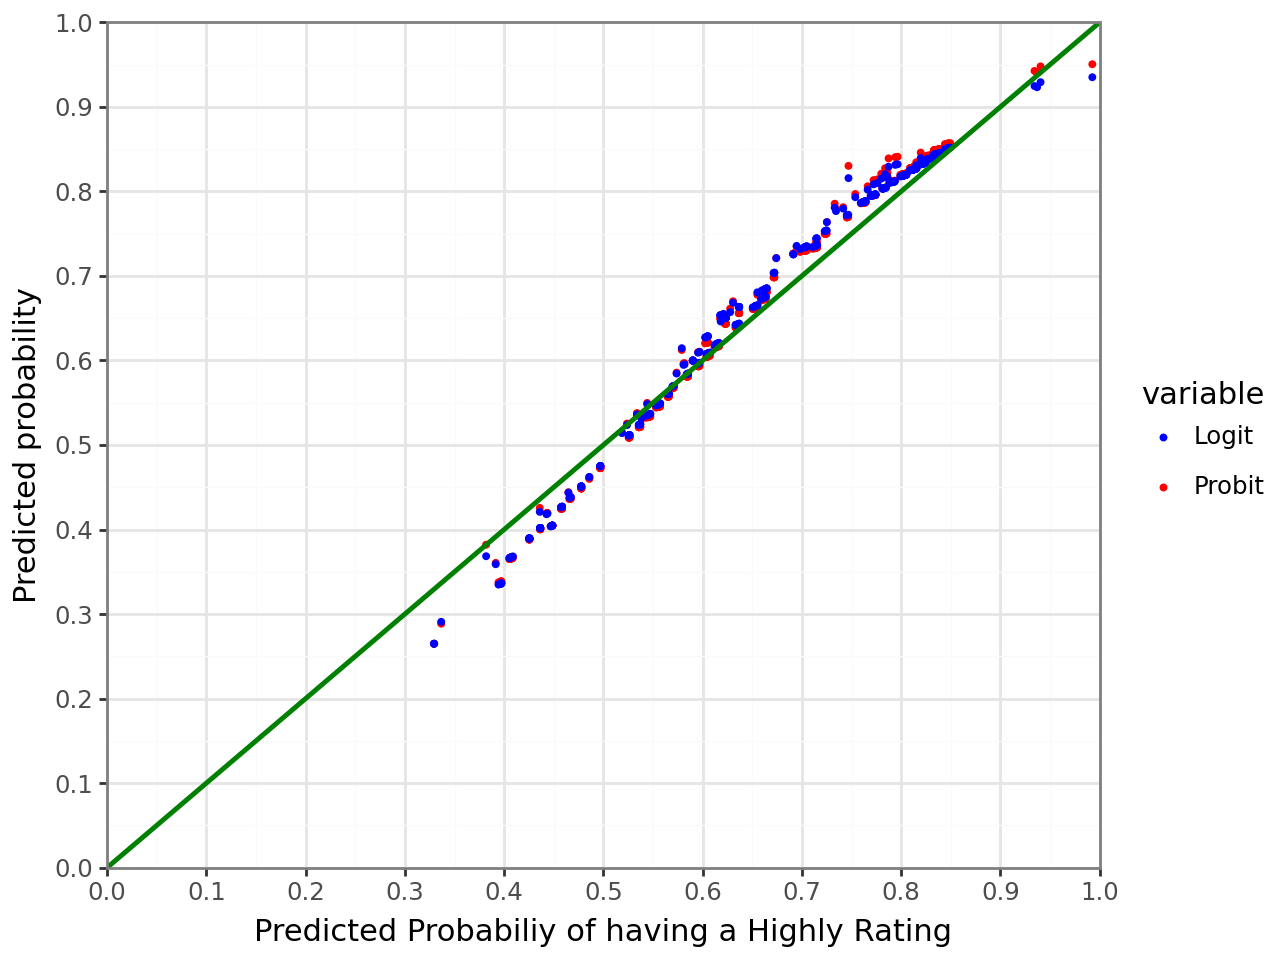

In [21]:
(
    ggplot(data=df_plot)
    + geom_point(aes(x="pred_lpm", y="value", color="variable"), size=0.6, na_rm=True)
    + geom_abline(intercept=0, slope=1, color="green", size=1)
    + labs(
        x="Predicted Probabiliy of having a Highly Rating", y="Predicted probability"
    )
    + scale_y_continuous(
        expand=[0.00, 0.0], limits=[0, 1], breaks=np.arange(0, 1.1, 0.1)
    )
    + scale_x_continuous(
        expand=[0.00, 0.0], limits=[0, 1], breaks=np.arange(0, 1.1, 0.1)
    )
    + scale_color_manual(name="", values=["blue", "red"])
    + theme_bw()
)